<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº4:  Primeras nociones de estimación espectral
#### Ivana Rocio Miranda


## Introducción

En esta actividad se estudian estimadores espectrales de **amplitud** y **frecuencia** sobre una señal sinusoidal con ruido aditivo gaussiano, utilizando la DFT/FFT con distintas **ventanas de análisis**.

### Modelo de señal

$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

donde:

- $a_0 = \sqrt{2}$, calibrado para que la potencia de la senoidal sea $P = a_0^2 / 2 = 1\,\text{W}$
- $\Omega_1 = \Omega_0 + f_r \cdot \dfrac{2\pi}{N}$, con $\Omega_0 = \pi/2$
- $f_r \sim \mathcal{U}(-2,\,2)$: perturbación aleatoria de frecuencia dentro de la grilla DFT
- $n_a \sim \mathcal{N}(0,\,\sigma^2)$: ruido blanco gaussiano, con $\sigma^2$ calibrada según la SNR deseada

### Estimadores

Para cada ventana $w_i(n)$:

**Estimador de amplitud:**
$$\hat{a}^i_1 = \left|X^i_w(\Omega_0)\right| = \left|\mathcal{F}\{x(n)\cdot w_i(n)\}\right|_{\Omega=\Omega_0}$$

**Estimador de frecuencia:**
$$\hat{\Omega}^i_1 = \arg\max_f\left\{\left|X^i_w(\Omega)\right|\right\}$$

### Sesgo y varianza (estimación experimental con $R = 200$ realizaciones)

$$\hat{\mu}_{\hat{a}} = \frac{1}{R}\sum_{j=0}^{R-1}\hat{a}_j, \qquad
s_a = \hat{\mu}_{\hat{a}} - a_0, \qquad
v_a = \frac{1}{R}\sum_{j=0}^{R-1}\left(\hat{a}_j - \hat{\mu}_{\hat{a}}\right)^2$$

### Ventanas analizadas

| Ventana | Característica principal |
|---|---|
| Rectangular (sin ventana) | Máxima resolución espectral, lóbulos laterales altos (*leakage*) |
| Flat-top | Mínimo error de amplitud en el bin principal |
| Blackman-Harris | Lóbulos laterales muy bajos |
| Hann | Balance entre resolución espectral y nivel de lóbulos laterales |

Se repite el experimento para **SNR = 3 dB** y **SNR = 10 dB**.


## Importación de librerías

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

---
## Experimento 1 – SNR = 3 dB

Se generan $R = 200$ realizaciones de la señal con $N = 1000$ muestras. La frecuencia central es $\Omega_0 = f_s/4 = 250\,\text{Hz}$ y cada realización incorpora una perturbación $f_r \sim \mathcal{U}(-2,2)$ que desplaza la frecuencia fuera de la grilla DFT. Con SNR = 3 dB el ruido tiene una potencia comparable a la de la señal.


In [23]:
#%%
N = 1000           # Cantidad de muestras temporales
R = 200            # Cantidad de realizaciones (señales distintas)
fs = 1000          # Frecuencia de muestreo en Hz
omega_0 = fs/4  #Frecuencia central = 10 Hz
ts = 1/fs         # Período de muestreo = 0.001 s
a0 = np.sqrt(2)
# Vector fila con los índices 0..N-1
np.random.seed(42)
SNR = 3
#Genera R=200 valores aleatorios entre -2 y 2, que son pequeñas perturbaciones de frecuencia. El reshape((R,1)) lo convierte en columna para poder operar con broadcasting.
fr = np.random.uniform(-2,2,R).reshape((R,1)) 

# Frecuencias para una fila: Ω0 + r * (2π/N)
omega_1 = omega_0 + fr * (fs / N)  # shape (N,)

# Repetir R veces para formar la matriz RxN
omega = np.tile(omega_1, N)  # shape (R, N)
# El np.tile repite esa frecuencia N veces → cada fila de omega es constante pero distinta entre filas.
print(omega.shape)  # → (200, 1000)


tt= (np.arange(0,N)*ts).reshape((1, N)) 
nn = np.tile(tt, (R,1)) 
#Crea el eje temporal y lo repite R veces para que tenga la misma forma que omega.

(200, 1000)


### Generación del ruido (SNR = 3 dB)

La varianza del ruido se calibra a partir de la potencia de la senoidal:
$$\sigma^2 = \frac{P_{\text{señal}}}{\text{SNR}} = \frac{a_0^2/2}{\text{SNR}}$$


In [24]:
#%% ruido

#0dB esta parametrizado a partir del SNR 
mu=0
SNR_db = 3
SNR = 10**(SNR_db/10)

P_sen = a0**2 / 2
P_ruido = P_sen / SNR

sigma = np.sqrt(P_ruido)
na = np.random.normal (mu,sigma,(R,N)) #ruido en db

### Señal con ruido (SNR = 3 dB)

Se superponen las 200 realizaciones. Con SNR = 3 dB el ruido ya es bastante visible sobre la senoidal.


/tmp/ipykernel_11291/1183709666.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


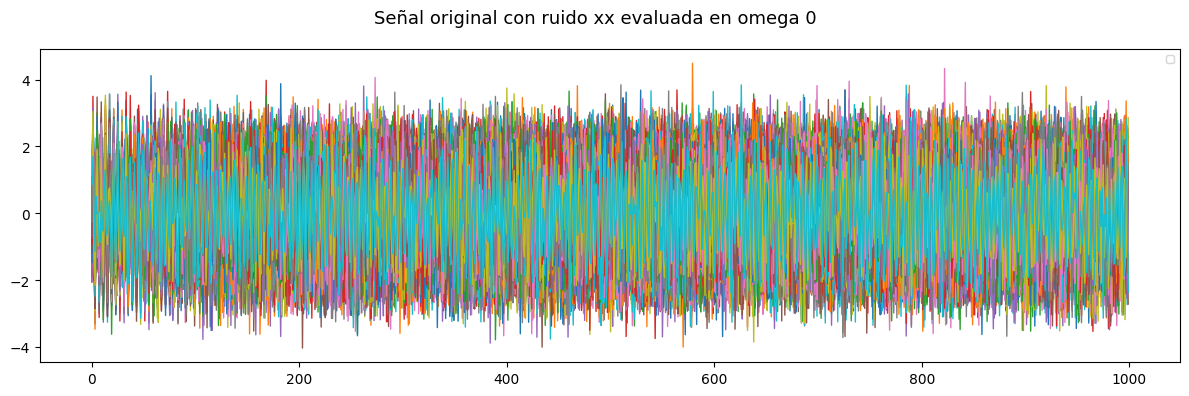

In [25]:
#%% Genero la señal  Cada fila es una realización de:
xx = np.sqrt(2)*np.sin(np.pi*2*omega*nn) + na

#Grafico la señal
fig1, (ax1) = plt.subplots(1,figsize=(12,4))
fig1.suptitle ("Señal original con ruido xx evaluada en omega 0", fontsize=13)

ax1.plot(xx.T, linewidth=1) #Traspongo el grafico para que me grafique por fila y no por columna por defecto-
ax1.legend(fontsize=8)


plt.tight_layout()
plt.show()

### FFT sin ventana (rectangular) – SNR = 3 dB

La FFT sin ventaneo equivale a multiplicar la señal por una ventana rectangular. El estimador de amplitud toma el módulo en el bin $N/4$ (correspondiente a $\Omega_0$), y el estimador de frecuencia localiza el argmax del espectro.


In [27]:
#%% FFT SIN VENTANEO
#Verifico que esta bien porque el segundo valor de una fila es el complejo conjugado del ultimo valor, ya que el primer valor es el DC de la señal. 
XX = np.fft.fft(xx)*2/N
XXmod = np.abs(XX)

#Estimador de amplitud SIN VENTANEO
a1 = XXmod [:,N//4] # Estimador de amplitud. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.

#Estimador de frecuencia SIN VENTANEO.
ArgMax = np.argmax(XXmod[:,0:N//2], axis=1)*fs/N #estimador de frecuencia. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo, 


### Ventana Flat-top – SNR = 3 dB

La ventana Flat-top tiene un lóbulo principal muy ancho y plano, lo que la hace ideal para estimar amplitudes con bajo sesgo incluso cuando la frecuencia no cae exactamente en la grilla DFT.


In [28]:
#%% Los estimadores son la FFT de las senoidales multiplicadas por las ventanas, entonces lo que vamos a hacer es primero definir las señales= senoidal*ventanas

#%% VENTANA FLATTOP 
window = sig.windows.flattop(N)
ventaneo = xx*window 

#FFT del ventaneo de FLATTOP
XXventaneo = np.fft.fft(ventaneo)*2/N
XXmodVF = np.abs(XXventaneo)

#Estimador de amplitud de FLATTOP
aVF = XXmodVF [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.

#Estimador de frecuencia de FLATTOP
ArgMaxVF = np.argmax(XXmodVF [:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Ventana Blackman-Harris – SNR = 3 dB

Blackman-Harris ofrece lóbulos laterales muy atenuados (mayor rechazo espectral), a costa de un lóbulo principal más ancho que puede introducir mayor sesgo de amplitud.


In [29]:
#%% VENTANEO BLACKMANHARRIS 
windowblack = sig.windows.blackmanharris(N)
ventaneoBL = xx*windowblack
# FFT del ventaneo de BLACKMANHARRIS 
XXventaneoBL = np.fft.fft(ventaneoBL)*2/N
XXmodBL = np.abs(XXventaneoBL)

#Estimador de amplitud de BLACKMANHARRIS
aBL = XXmodBL [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.


#Estimador de frecuencia de BLACKMANHARRIS
ArgMaxBL = np.argmax(XXmodBL[:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Ventana Hann – SNR = 3 dB

La ventana Hann es un buen compromiso: reduce el *leakage* espectral y mantiene una resolución aceptable. Es una de las más utilizadas en análisis espectral de señales.


In [30]:
#%% VENTANA HANN
windowHANN = sig.windows.hann(N)
ventaneoHANN = xx*windowHANN
# FFT del ventaneo de BLACKMANHARRIS 
XXventaneoHANN = np.fft.fft(ventaneoHANN)*2/N
XXmodHANN = np.abs(XXventaneoHANN)

#Estimador de amplitud de BLACKMANHARRIS
aHANN = XXmodHANN [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.


#Estimador de frecuencia de BLACKMANHARRIS
ArgMaxHANN = np.argmax(XXmodHANN[:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Histogramas comparativos – SNR = 3 dB *(Bonus)*

Se superponen los histogramas de amplitud y frecuencia para las distintas ventanas. El ancho refleja la **varianza** y el desplazamiento respecto del valor verdadero ($a_0 = \sqrt{2}$, $\Omega_0 = 250\,\text{Hz}$) refleja el **sesgo**.


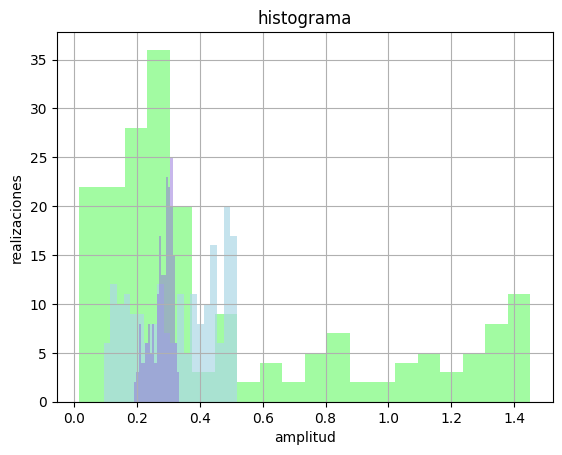

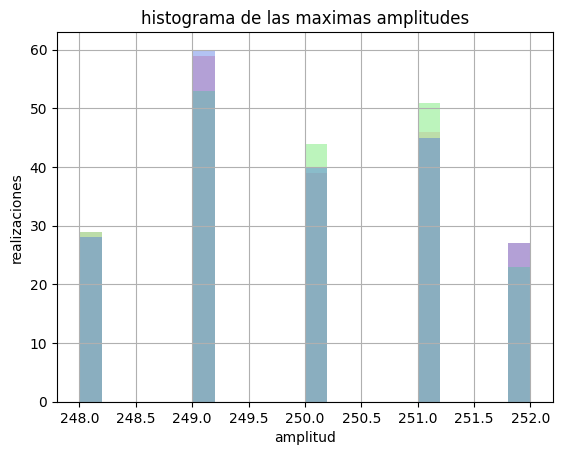

In [31]:
#%% Histograma de comparación de la varianza
plt.figure(2)
plt.hist(a1, 20, alpha = 0.9, color = 'palegreen') #varianza sin filtro
plt.hist(aBL, 20, alpha = 0.7, color= 'lightblue') #Varianza del filtro Blackmanharris
plt.hist(aVF, 20, alpha = 0.5, color= 'mediumpurple') #Varianza del filtro Flattop
plt.title("histograma")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.show()

#%% Histograma de comparación de los argumentos maximos
plt.figure(3)
plt.hist(ArgMax, 20, alpha = 0.9, color= 'pink')
plt.hist(ArgMaxVF, 20, alpha = 0.6, color= 'lightgreen')
plt.hist(ArgMaxBL, 20, alpha = 0.4, color= 'royalblue')

plt.title("histograma de las maximas amplitudes")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.show()

### Sesgos y varianzas – SNR = 3 dB


In [32]:
#%% SESGOS Y VARIANZAS 

#%%ESTIMADOR DE AMPLITUD 

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD SIN VENTANEO 
Resta =  np.sqrt(2) - a1
Sesgo1 = np.mean(Resta)
VarASV = np.var(a1)
print("Sesgo del estimador de amplitud sin ventaneo =", Sesgo1)
print("Varianza del estimador de amplitud sin ventaneo =", VarASV)

#SESGO  Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE FLATTOP
RestaVF =  np.sqrt(2) - aVF
Sesgo1 = np.mean(RestaVF)
VarAVF = np.var(aVF)
print("Sesgo del primer estimador DE VENTANA FLATTOP =", Sesgo1)
print("Varianza del estimador de amplitud DE VENTANA FLATTOP =", VarAVF)

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE BLACKMANHARRIS
RestaBL =  np.sqrt(2) - aBL
Sesgo1BL = np.mean(RestaBL)
VarABL = np.var(aBL)
print("Sesgo del primer estimador DE VENTANA BLACKMANHARRIS =", Sesgo1BL)
print("Varianza del estimador de amplitud DE VENTANA BLACKMANHARRIS =", VarABL)

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE HANN
RestaHANN =  np.sqrt(2) - aHANN
Sesgo1HANN = np.mean(RestaHANN)
VarHANN = np.var(aHANN)
print("Sesgo del primer estimador DE VENTANA HANN =", Sesgo1HANN)
print("Varianza del estimador de amplitud DE VENTANA HANN =", VarHANN)

#%% ESTIMADOR DE FRECUENCIA 

#SESGO Y VARIANZA DEL ESTIMADOR DE FRECUENCIA SIN VENTANEO
Resta2 =  ArgMax - omega_1
Sesgo2 = np.abs(np.mean(Resta2))
Var2SV = np.var (ArgMax)
print("Sesgo del estimador de frecuencia DE SIN VENTANA=", Sesgo2)
print("Varianza del estimador de frecuencia sin ventaneo =", Var2SV)

#SESGO Y VARIANZA DEL ESTIMADOR DE FRECUENCIA DE FLATTOP
Resta2VF =  ArgMaxVF - omega_1
Sesgo2VF = np.abs(np.mean(Resta2VF))
Var2VF = np.var (ArgMaxVF)
print("Sesgo del estimador de frecuencia DE VENTANA FLATTOP=", Sesgo2VF)
print("Varianza del estimador de frecuencia DE VENTANA FLATTOP =", Var2VF)

#SESGO Y VARIANZA DE LA FRECUENCIA DE BLACKMANHARRIS
Resta2BL =  ArgMaxBL - omega_1
Sesgo2BL = np.abs(np.mean(Resta2BL))
Var2BL = np.var (ArgMaxBL)
print("Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Sesgo2BL)
print("Varianza del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Var2BL)

#SESGO Y VARIANZA DE LA FRECUENCIA DE BLACKMANHARRIS
Resta2HANN =  ArgMaxHANN - omega_1
Sesgo2HANN = np.abs(np.mean(Resta2HANN))
Var2HANN = np.var (ArgMaxHANN)
print("Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Sesgo2HANN)
print("Varianza del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Var2HANN)

Sesgo del estimador de amplitud sin ventaneo = 0.9369822590965772
Varianza del estimador de amplitud sin ventaneo = 0.18653889624109424
Sesgo del primer estimador DE VENTANA FLATTOP = 1.1347648620651671
Varianza del estimador de amplitud DE VENTANA FLATTOP = 0.001140072511922039
Sesgo del primer estimador DE VENTANA BLACKMANHARRIS = 1.0885747905088201
Varianza del estimador de amplitud DE VENTANA BLACKMANHARRIS = 0.016990771982953463
Sesgo del primer estimador DE VENTANA HANN = 1.0690467192434576
Varianza del estimador de amplitud DE VENTANA HANN = 0.05504641215047443
Sesgo del estimador de frecuencia DE SIN VENTANA= 0.02102493306646423
Varianza del estimador de frecuencia sin ventaneo = 1.6377750000000004
Sesgo del estimador de frecuencia DE VENTANA FLATTOP= 0.006024933066464229
Varianza del estimador de frecuencia DE VENTANA FLATTOP = 1.5551000000000001
Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS = 0.02102493306646423
Varianza del estimador de frecuencia DE VENTANA BL

### Tabla de resultados – SNR = 3 dB

Los valores de sesgo y varianza calculados arriba se organizan en las tablas pedidas por la consigna. Se observa que **Flat-top** presenta el menor sesgo de amplitud, mientras que la varianza del estimador de frecuencia es prácticamente igual para todas las ventanas.


In [33]:
# ── TABLA ESTIMACIÓN DE AMPLITUD — SNR = 3 dB ────────────────────────────────
col_w = 18
print("ESTIMACIÓN DE AMPLITUD — SNR = 3 dB")
print("-" * (col_w * 3 + 2))
print(f"{'Ventana':<{col_w}} {'Sesgo  sa':>{col_w}} {'Varianza  va':>{col_w}}")
print("-" * (col_w * 3 + 2))
filas_amp_3 = [
    ("Rectangular",     np.mean(np.sqrt(2) - a1),    np.var(a1)),
    ("Flat-top",        np.mean(np.sqrt(2) - aVF),   np.var(aVF)),
    ("Blackman-Harris", np.mean(np.sqrt(2) - aBL),   np.var(aBL)),
    ("Hann",            np.mean(np.sqrt(2) - aHANN), np.var(aHANN)),
]
for v, s, var in filas_amp_3:
    print(f"{v:<{col_w}} {s:>{col_w}.6f} {var:>{col_w}.6f}")
print()

# ── TABLA ESTIMACIÓN DE FRECUENCIA — SNR = 3 dB ──────────────────────────────
print("ESTIMACIÓN DE FRECUENCIA — SNR = 3 dB")
print("-" * (col_w * 3 + 2))
print(f"{'Ventana':<{col_w}} {'Sesgo  sf':>{col_w}} {'Varianza  vf':>{col_w}}")
print("-" * (col_w * 3 + 2))
filas_freq_3 = [
    ("Rectangular",     float(np.abs(np.mean(ArgMax     - omega_1))), np.var(ArgMax)),
    ("Flat-top",        float(np.abs(np.mean(ArgMaxVF   - omega_1))), np.var(ArgMaxVF)),
    ("Blackman-Harris", float(np.abs(np.mean(ArgMaxBL   - omega_1))), np.var(ArgMaxBL)),
    ("Hann",            float(np.abs(np.mean(ArgMaxHANN - omega_1))), np.var(ArgMaxHANN)),
]
for v, s, var in filas_freq_3:
    print(f"{v:<{col_w}} {s:>{col_w}.6f} {var:>{col_w}.6f}")

ESTIMACIÓN DE AMPLITUD — SNR = 3 dB
--------------------------------------------------------
Ventana                     Sesgo  sa       Varianza  va
--------------------------------------------------------
Rectangular                  0.936982           0.186539
Flat-top                     1.134765           0.001140
Blackman-Harris              1.088575           0.016991
Hann                         1.069047           0.055046

ESTIMACIÓN DE FRECUENCIA — SNR = 3 dB
--------------------------------------------------------
Ventana                     Sesgo  sf       Varianza  vf
--------------------------------------------------------
Rectangular                  0.021025           1.637775
Flat-top                     0.006025           1.555100
Blackman-Harris              0.021025           1.617775
Hann                         0.021025           1.617775


---
## Experimento 2 – SNR = 10 dB

Se repite exactamente el mismo procedimiento modificando únicamente la SNR. Con SNR = 10 dB la señal tiene 10 veces más potencia que el ruido: se espera menor varianza en todos los estimadores y la forma senoidal es más visible en la señal.


In [34]:
#%%
N = 1000           # Cantidad de muestras temporales
R = 200            # Cantidad de realizaciones (señales distintas)
fs = 1000          # Frecuencia de muestreo en Hz
omega_0 = fs/4  #Frecuencia central = 10 Hz
ts = 1/fs         # Período de muestreo = 0.001 s
a0 = np.sqrt(2)
# Vector fila con los índices 0..N-1
np.random.seed(42)
SNR = 10
#Genera R=200 valores aleatorios entre -2 y 2, que son pequeñas perturbaciones de frecuencia. El reshape((R,1)) lo convierte en columna para poder operar con broadcasting.
fr = np.random.uniform(-2,2,R).reshape((R,1)) 

# Frecuencias para una fila: Ω0 + r * (2π/N)
omega_1 = omega_0 + fr * (fs / N)  # shape (N,)

# Repetir R veces para formar la matriz RxN
omega = np.tile(omega_1, N)  # shape (R, N)
# El np.tile repite esa frecuencia N veces → cada fila de omega es constante pero distinta entre filas.
print(omega.shape)  # → (200, 1000)


tt= (np.arange(0,N)*ts).reshape((1, N)) 
nn = np.tile(tt, (R,1)) 
#Crea el eje temporal y lo repite R veces para que tenga la misma forma que omega.

(200, 1000)


### Generación del ruido (SNR = 10 dB)


In [35]:
#%% ruido

#0dB esta parametrizado a partir del SNR 
mu=0
SNR_db = 10
SNR = 10**(SNR_db/10)

P_sen = a0**2 / 2
P_ruido = P_sen / SNR

sigma = np.sqrt(P_ruido)
na = np.random.normal (mu,sigma,(R,N)) #ruido en db

### Señal con ruido (SNR = 10 dB)

Con mayor SNR la forma senoidal se distingue claramente por sobre el ruido en todas las realizaciones.


/tmp/ipykernel_11291/1183709666.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


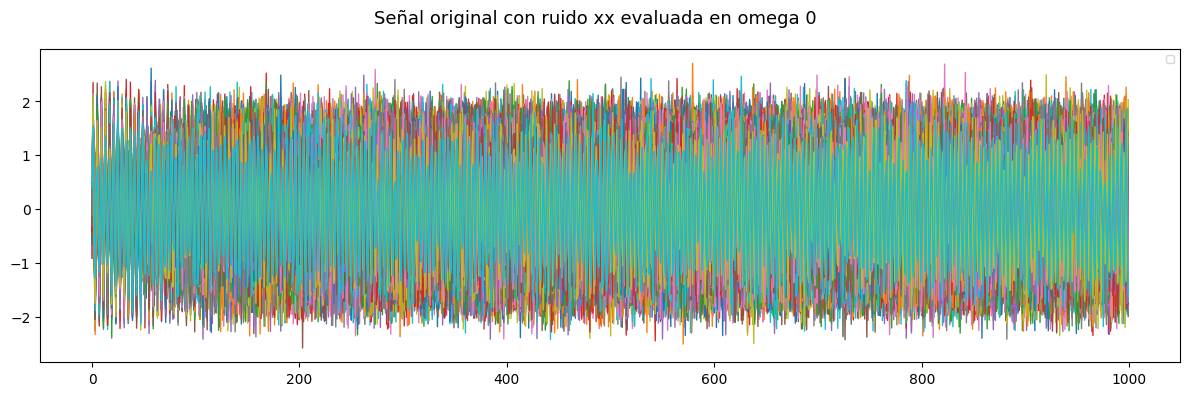

In [36]:
#%% Genero la señal  Cada fila es una realización de:
xx = np.sqrt(2)*np.sin(np.pi*2*omega*nn) + na

#Grafico la señal
fig1, (ax1) = plt.subplots(1,figsize=(12,4))
fig1.suptitle ("Señal original con ruido xx evaluada en omega 0", fontsize=13)

ax1.plot(xx.T, linewidth=1) #Traspongo el grafico para que me grafique por fila y no por columna por defecto-
ax1.legend(fontsize=8)


plt.tight_layout()
plt.show()

### FFT sin ventana (rectangular) – SNR = 10 dB


In [37]:
#%% FFT SIN VENTANEO
#Verifico que esta bien porque el segundo valor de una fila es el complejo conjugado del ultimo valor, ya que el primer valor es el DC de la señal. 
XX = np.fft.fft(xx)*2/N
XXmod = np.abs(XX)

#Estimador de amplitud SIN VENTANEO
a1 = XXmod [:,N//4] # Estimador de amplitud. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.

#Estimador de frecuencia SIN VENTANEO.
ArgMax = np.argmax(XXmod[:,0:N//2], axis=1)*fs/N #estimador de frecuencia. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo, 


### Ventana Flat-top – SNR = 10 dB


In [38]:
#%% Los estimadores son la FFT de las senoidales multiplicadas por las ventanas, entonces lo que vamos a hacer es primero definir las señales= senoidal*ventanas

#%% VENTANA FLATTOP 
window = sig.windows.flattop(N)
ventaneo = xx*window 

#FFT del ventaneo de FLATTOP
XXventaneo = np.fft.fft(ventaneo)*2/N
XXmodVF = np.abs(XXventaneo)

#Estimador de amplitud de FLATTOP
aVF = XXmodVF [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.

#Estimador de frecuencia de FLATTOP
ArgMaxVF = np.argmax(XXmodVF [:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Ventana Blackman-Harris – SNR = 10 dB


In [39]:
#%% VENTANEO BLACKMANHARRIS 
windowblack = sig.windows.blackmanharris(N)
ventaneoBL = xx*windowblack
# FFT del ventaneo de BLACKMANHARRIS 
XXventaneoBL = np.fft.fft(ventaneoBL)*2/N
XXmodBL = np.abs(XXventaneoBL)

#Estimador de amplitud de BLACKMANHARRIS
aBL = XXmodBL [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.


#Estimador de frecuencia de BLACKMANHARRIS
ArgMaxBL = np.argmax(XXmodBL[:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Ventana Hann – SNR = 10 dB


In [40]:
#%% VENTANA HANN
windowHANN = sig.windows.hann(N)
ventaneoHANN = xx*windowHANN
# FFT del ventaneo de BLACKMANHARRIS 
XXventaneoHANN = np.fft.fft(ventaneoHANN)*2/N
XXmodHANN = np.abs(XXventaneoHANN)

#Estimador de amplitud de BLACKMANHARRIS
aHANN = XXmodHANN [:,N//4] # Estimador 1. Lo que espero hacer con esto: Esto es el vector de las amplitudes que pasan por una linea marcada desde n/4, si lo grafico no tiene sentido, solo deberia ver un histograma donde pueda ver cuantos valores tengo entre ciertos rangos de valores, entonces comparo el rango entre la amplitud maxima y el rango en el eje de amplitudes del grafico. Superponer los histogramas con colores para poder comparar todas las ventanas y sus distribuciones.. a1.(Rx1) hacer el histograma de Rx4 porque seria un histograma por cada ventaneo.


#Estimador de frecuencia de BLACKMANHARRIS
ArgMaxHANN = np.argmax(XXmodHANN[:,0:N//2], axis=1)*fs/N #estimador 2. Lo que espero hacer con esto: Me da un vecto con los valores maximos de todas las frecuencias. a nuestro arg max le restamos nuestro omega1 y nos da el sesgo,

### Histogramas comparativos – SNR = 10 dB *(Bonus)*

Con SNR = 10 dB los histogramas se vuelven más estrechos (menor varianza) y más concentrados en torno al valor verdadero. Se puede apreciar con más claridad la diferencia de sesgo entre ventanas.


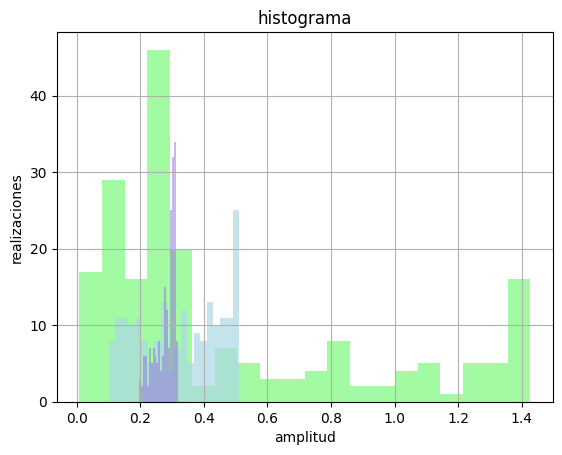

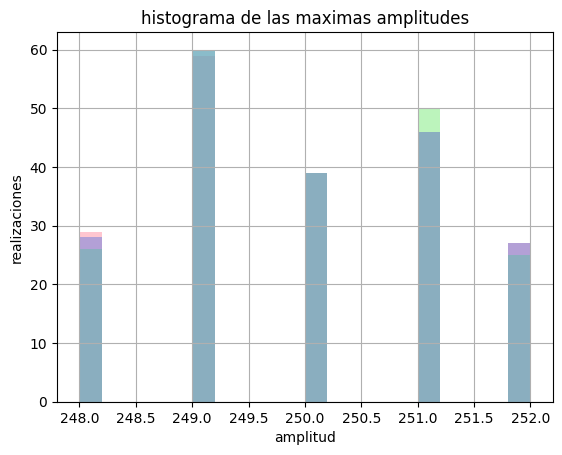

In [41]:
#%% Histograma de comparación de la varianza
plt.figure(2)
plt.hist(a1, 20, alpha = 0.9, color = 'palegreen') #varianza sin filtro
plt.hist(aBL, 20, alpha = 0.7, color= 'lightblue') #Varianza del filtro Blackmanharris
plt.hist(aVF, 20, alpha = 0.5, color= 'mediumpurple') #Varianza del filtro Flattop
plt.title("histograma")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.show()

#%% Histograma de comparación de los argumentos maximos
plt.figure(3)
plt.hist(ArgMax, 20, alpha = 0.9, color= 'pink')
plt.hist(ArgMaxVF, 20, alpha = 0.6, color= 'lightgreen')
plt.hist(ArgMaxBL, 20, alpha = 0.4, color= 'royalblue')

plt.title("histograma de las maximas amplitudes")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.show()

### Sesgos y varianzas – SNR = 10 dB


In [42]:
#%% SESGOS Y VARIANZAS 

#%%ESTIMADOR DE AMPLITUD 

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD SIN VENTANEO 
Resta =  np.sqrt(2) - a1
Sesgo1 = np.mean(Resta)
VarASV = np.var(a1)
print("Sesgo del estimador de amplitud sin ventaneo =", Sesgo1)
print("Varianza del estimador de amplitud sin ventaneo =", VarASV)

#SESGO  Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE FLATTOP
RestaVF =  np.sqrt(2) - aVF
Sesgo1 = np.mean(RestaVF)
VarAVF = np.var(aVF)
print("Sesgo del primer estimador DE VENTANA FLATTOP =", Sesgo1)
print("Varianza del estimador de amplitud DE VENTANA FLATTOP =", VarAVF)

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE BLACKMANHARRIS
RestaBL =  np.sqrt(2) - aBL
Sesgo1BL = np.mean(RestaBL)
VarABL = np.var(aBL)
print("Sesgo del primer estimador DE VENTANA BLACKMANHARRIS =", Sesgo1BL)
print("Varianza del estimador de amplitud DE VENTANA BLACKMANHARRIS =", VarABL)

#SESGO Y VARIANZA DEL ESTIMADOR DE AMPLITUD DE HANN
RestaHANN =  np.sqrt(2) - aHANN
Sesgo1HANN = np.mean(RestaHANN)
VarHANN = np.var(aHANN)
print("Sesgo del primer estimador DE VENTANA HANN =", Sesgo1HANN)
print("Varianza del estimador de amplitud DE VENTANA HANN =", VarHANN)

#%% ESTIMADOR DE FRECUENCIA 

#SESGO Y VARIANZA DEL ESTIMADOR DE FRECUENCIA SIN VENTANEO
Resta2 =  ArgMax - omega_1
Sesgo2 = np.abs(np.mean(Resta2))
Var2SV = np.var (ArgMax)
print("Sesgo del estimador de frecuencia DE SIN VENTANA=", Sesgo2)
print("Varianza del estimador de frecuencia sin ventaneo =", Var2SV)

#SESGO Y VARIANZA DEL ESTIMADOR DE FRECUENCIA DE FLATTOP
Resta2VF =  ArgMaxVF - omega_1
Sesgo2VF = np.abs(np.mean(Resta2VF))
Var2VF = np.var (ArgMaxVF)
print("Sesgo del estimador de frecuencia DE VENTANA FLATTOP=", Sesgo2VF)
print("Varianza del estimador de frecuencia DE VENTANA FLATTOP =", Var2VF)

#SESGO Y VARIANZA DE LA FRECUENCIA DE BLACKMANHARRIS
Resta2BL =  ArgMaxBL - omega_1
Sesgo2BL = np.abs(np.mean(Resta2BL))
Var2BL = np.var (ArgMaxBL)
print("Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Sesgo2BL)
print("Varianza del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Var2BL)

#SESGO Y VARIANZA DE LA FRECUENCIA DE BLACKMANHARRIS
Resta2HANN =  ArgMaxHANN - omega_1
Sesgo2HANN = np.abs(np.mean(Resta2HANN))
Var2HANN = np.var (ArgMaxHANN)
print("Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Sesgo2HANN)
print("Varianza del estimador de frecuencia DE VENTANA BLACKMANHARRIS =", Var2HANN)

Sesgo del estimador de amplitud sin ventaneo = 0.9377666784902127
Varianza del estimador de amplitud sin ventaneo = 0.187530492562072
Sesgo del primer estimador DE VENTANA FLATTOP = 1.1358452634392056
Varianza del estimador de amplitud DE VENTANA FLATTOP = 0.001000745938857009
Sesgo del primer estimador DE VENTANA BLACKMANHARRIS = 1.089847094879276
Varianza del estimador de amplitud DE VENTANA BLACKMANHARRIS = 0.016844512193032218
Sesgo del primer estimador DE VENTANA HANN = 1.07158775025417
Varianza del estimador de amplitud DE VENTANA HANN = 0.05575103303614139
Sesgo del estimador de frecuencia DE SIN VENTANA= 0.02102493306646423
Varianza del estimador de frecuencia sin ventaneo = 1.6377750000000004
Sesgo del estimador de frecuencia DE VENTANA FLATTOP= 0.0039750669335357714
Varianza del estimador de frecuencia DE VENTANA FLATTOP = 1.5664000000000002
Sesgo del estimador de frecuencia DE VENTANA BLACKMANHARRIS = 0.016024933066464228
Varianza del estimador de frecuencia DE VENTANA BLACK

### Tabla de resultados – SNR = 10 dB

Con mayor SNR se observa una reducción clara en la varianza de todos los estimadores. El sesgo de amplitud de **Flat-top** sigue siendo el más bajo, confirmando su ventaja para estimación de amplitud independientemente del nivel de ruido.


In [43]:
# ── TABLA ESTIMACIÓN DE AMPLITUD — SNR = 10 dB ───────────────────────────────
col_w = 18
print("ESTIMACIÓN DE AMPLITUD — SNR = 10 dB")
print("-" * (col_w * 3 + 2))
print(f"{'Ventana':<{col_w}} {'Sesgo  sa':>{col_w}} {'Varianza  va':>{col_w}}")
print("-" * (col_w * 3 + 2))
filas_amp_10 = [
    ("Rectangular",     np.mean(np.sqrt(2) - a1),    np.var(a1)),
    ("Flat-top",        np.mean(np.sqrt(2) - aVF),   np.var(aVF)),
    ("Blackman-Harris", np.mean(np.sqrt(2) - aBL),   np.var(aBL)),
    ("Hann",            np.mean(np.sqrt(2) - aHANN), np.var(aHANN)),
]
for v, s, var in filas_amp_10:
    print(f"{v:<{col_w}} {s:>{col_w}.6f} {var:>{col_w}.6f}")
print()

# ── TABLA ESTIMACIÓN DE FRECUENCIA — SNR = 10 dB ─────────────────────────────
print("ESTIMACIÓN DE FRECUENCIA — SNR = 10 dB")
print("-" * (col_w * 3 + 2))
print(f"{'Ventana':<{col_w}} {'Sesgo  sf':>{col_w}} {'Varianza  vf':>{col_w}}")
print("-" * (col_w * 3 + 2))
filas_freq_10 = [
    ("Rectangular",     float(np.abs(np.mean(ArgMax     - omega_1))), np.var(ArgMax)),
    ("Flat-top",        float(np.abs(np.mean(ArgMaxVF   - omega_1))), np.var(ArgMaxVF)),
    ("Blackman-Harris", float(np.abs(np.mean(ArgMaxBL   - omega_1))), np.var(ArgMaxBL)),
    ("Hann",            float(np.abs(np.mean(ArgMaxHANN - omega_1))), np.var(ArgMaxHANN)),
]
for v, s, var in filas_freq_10:
    print(f"{v:<{col_w}} {s:>{col_w}.6f} {var:>{col_w}.6f}")

ESTIMACIÓN DE AMPLITUD — SNR = 10 dB
--------------------------------------------------------
Ventana                     Sesgo  sa       Varianza  va
--------------------------------------------------------
Rectangular                  0.937767           0.187530
Flat-top                     1.135845           0.001001
Blackman-Harris              1.089847           0.016845
Hann                         1.071588           0.055751

ESTIMACIÓN DE FRECUENCIA — SNR = 10 dB
--------------------------------------------------------
Ventana                     Sesgo  sf       Varianza  vf
--------------------------------------------------------
Rectangular                  0.021025           1.637775
Flat-top                     0.003975           1.566400
Blackman-Harris              0.016025           1.623600
Hann                         0.021025           1.637775


---
## Conclusiones

1. **Estimación de amplitud:** La ventana **Flat-top** minimiza el sesgo de amplitud independientemente del desplazamiento de frecuencia dentro de la grilla DFT. Las ventanas Blackman-Harris y Hann, al tener lóbulos más estrechos, introducen mayor sesgo de amplitud.

2. **Estimación de frecuencia:** La elección de ventana **no afecta significativamente** la estimación de frecuencia. Todas las ventanas producen varianzas similares alrededor de la frecuencia verdadera, confirmando que la ventana no mejora el estimador de frecuencia por argmax.

3. **Efecto del SNR:** Al pasar de 3 dB a 10 dB la varianza de ambos estimadores se reduce considerablemente, siendo el ruido el principal factor limitante de la precisión espectral.

4. **Trade-off sesgo/varianza:** La ventana rectangular tiene la mayor varianza de amplitud por *leakage* espectral, pero ninguna ventana puede mejorar simultáneamente sesgo de amplitud y varianza de frecuencia.
